In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Load Data
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

In [3]:
# Show table
train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
train.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Replace ? with NaN
train = train.replace(" ?",np.nan)
test = test.replace(" ?",np.nan)

In [7]:
# Calculating Duplicated Data
train.duplicated().sum()

np.int64(24)

In [8]:
# Removing Duplicated Data
train = train.drop_duplicates()

In [9]:
# Clean Column Names
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

In [10]:
# Separate features and target
x_train = train.drop("Income",axis=1)
y_train = train["Income"]

x_test = test.drop("Income",axis=1)
y_test = test["Income"]

In [11]:
# Clean target values
y_train = y_train.astype(str).str.strip().str.replace(".", "", regex=False)
y_test = y_test.astype(str).str.strip().str.replace(".", "", regex=False)

# Check values before encoding
print(y_train.unique())
print(y_test.unique())

['<=50K' '>50K']
['<=50K' '>50K']


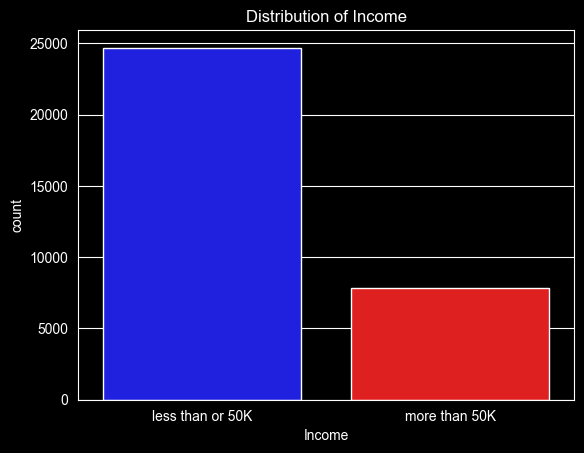

In [40]:
#Visualize the difference in the number of people who earn less than 50k and the ones that earn more
sns.countplot(x=y_train,hue=y_train, palette={0: "blue", 1: "red"}, legend=False)
plt.title('Distribution of Income')
plt.xticks(ticks=[0, 1], labels=['less than or 50K', 'more than 50K'])
plt.show()

In [12]:
x_train['native-country'] = x_train['native-country'].apply(lambda x: ' United-States' if x == 'United-States' else 'Others')

x_test['native-country'] = x_test['native-country'].apply(lambda x: ' United-States' if x == 'United-States' else 'Others')

In [13]:
# Encode Target
y_train = y_train.map({"<=50K": 0, ">50K": 1})
y_test = y_test.map({"<=50K": 0, ">50K": 1})

In [14]:
# Replace non-numerical Values with mode
# and the numerical with mean
for col in x_train.columns:
    if not pd.api.types.is_numeric_dtype(x_train[col]):  # any non-numeric → mode
        mode_val = x_train[col].mode()[0]
        x_train[col] = x_train[col].fillna(mode_val)
        x_test[col]  = x_test[col].fillna(mode_val)
    else:  # numeric → mean
        mean_val = x_train[col].mean()
        x_train[col] = x_train[col].fillna(mean_val)
        x_test[col]  = x_test[col].fillna(mean_val)

In [15]:
# Create net-capital first
x_train["net-capital"] = x_train["capital-gain"] - x_train["capital-loss"]
x_test["net-capital"]  = x_test["capital-gain"]  - x_test["capital-loss"]

In [16]:
# Drop Meaningless Features

############################### E7naaaa 3mlnaaa comments 3la race w sex


# x_train = x_train.drop(["education", "fnlwgt", "race", "capital-gain", "capital-loss","native-country","sex"], axis=1)
# x_test = x_test.drop(["education", "fnlwgt" , "race" , "capital-gain", "capital-loss","native-country","sex" ], axis=1)

x_train = x_train.drop(["education", "fnlwgt",  "capital-gain", "capital-loss"], axis=1)
x_test = x_test.drop(["education", "fnlwgt",  "capital-gain", "capital-loss"], axis=1)


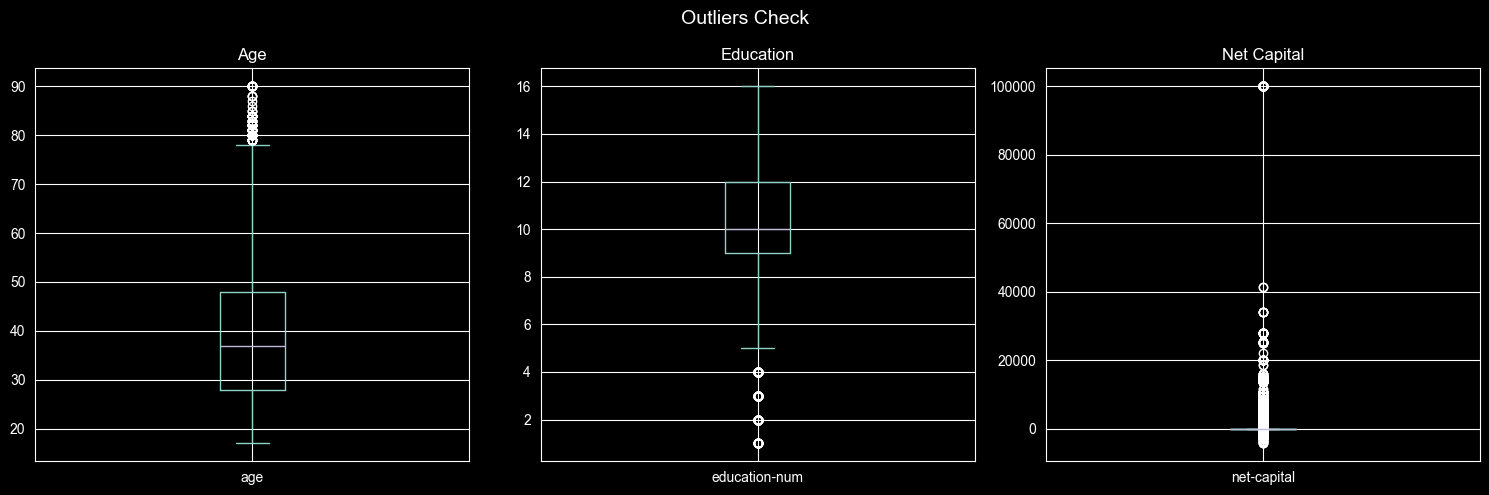

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_train["age"].plot(kind="box", ax=axes[0], title="Age")
x_train["education-num"].plot(kind="box", ax=axes[1], title="Education")
x_train["net-capital"].plot(kind="box", ax=axes[2], title="Net Capital")

plt.suptitle("Outliers Check", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# 1. Cap Age outliers
Q1 = x_train["age"].quantile(0.25)
Q3 = x_train["age"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

x_train["age"] = x_train["age"].clip(upper=upper)
x_test["age"]  = x_test["age"].clip(upper=upper)


In [19]:

# cat_cols = ["workclass", "marital-status", "occupation", "relationship"]
cat_cols = ["workclass", "marital-status", "occupation", "relationship","race","sex","native-country"]
# OneHot Encoding
x_train = pd.get_dummies(x_train, columns=cat_cols,dtype=int)
x_test = pd.get_dummies(x_test, columns=cat_cols,dtype=int)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [20]:
x_train

,age,education-num,hours-per-week,net-capital,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,relationship_ Unmarried,relationship_ Wife,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,native-country_Others
0,39,13,40,2174,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1
1,50,13,13,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,1
2,38,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,1
3,53,7,40,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,1
4,28,13,40,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,38,0,0,0,0,1,0,0,...,0,1,0,0,0,0,1,1,0,1
32557,40,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,1
32558,58,9,40,0,0,0,0,1,0,0,...,1,0,0,0,0,0,1,1,0,1
32559,22,9,20,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,1


Income                                   1.000000
marital-status_ Married-civ-spouse       0.444609
relationship_ Husband                    0.400941
education-num                            0.335272
age                                      0.235830
hours-per-week                           0.229658
sex_ Male                                0.215969
occupation_ Exec-managerial              0.214889
net-capital                              0.214437
workclass_ Self-emp-inc                  0.139446
relationship_ Wife                       0.123230
occupation_ Prof-specialty               0.112919
race_ White                              0.085235
workclass_ Federal-gov                   0.059337
workclass_ Local-gov                     0.033027
workclass_ Self-emp-not-inc              0.030017
occupation_ Protective-serv              0.028086
occupation_ Tech-support                 0.025773
occupation_ Sales                        0.023598
workclass_ State-gov                     0.014791


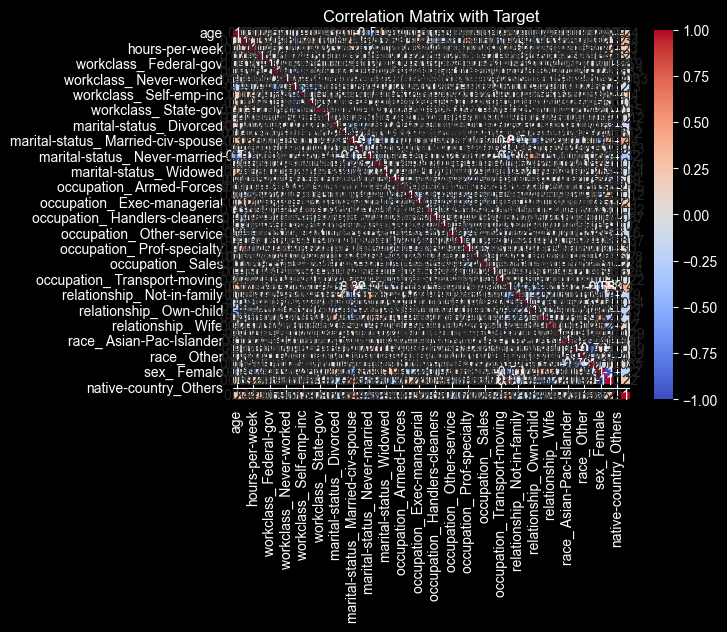

In [21]:
# Temporarily combine for correlation
train_df = pd.concat([x_train, y_train], axis=1)

# 1. Correlation with target only
corr = train_df.corr()
print(corr[y_train.name].sort_values(ascending=False))

# 2. Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix with Target')
plt.show()

In [22]:
scaler = MinMaxScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test  = pd.DataFrame(scaler.transform(x_test),      columns=x_test.columns)

In [48]:
#Function to display a confusion matrix for each model

def plot_model_results(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
    disp.plot(cmap='Blues', ax=ax, values_format='d')

    plt.title(f'{model_name} Results\nAccuracy: {acc:.4f}')
    plt.show()

Accuracy: 0.8449


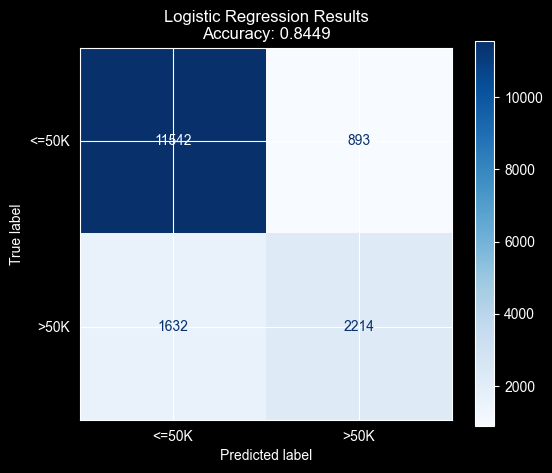

In [49]:
# Logistic Model

# 1. Train the model
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

# 2. Predict
y_pred = model.predict(x_test)

# 3. Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

#v 4. Visualization
plot_model_results(y_test, y_pred, "Logistic Regression")

Accuracy: 0.8409
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     12435
           1       0.72      0.54      0.61      3846

    accuracy                           0.84     16281
   macro avg       0.79      0.74      0.76     16281
weighted avg       0.83      0.84      0.83     16281



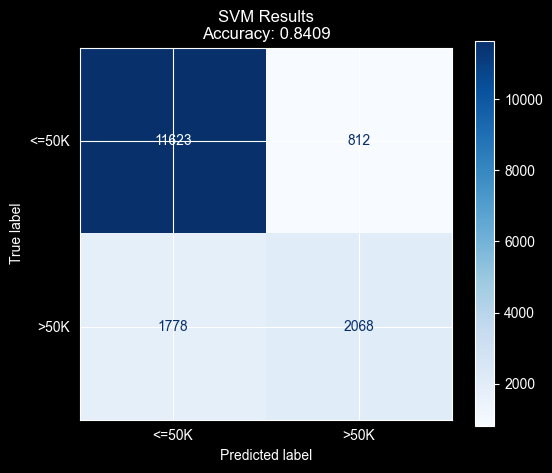

In [54]:
# SVM Model

# 1. Train the model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train, y_train)

# 2. Predict
y_pred_svm = svm_model.predict(x_test)

# 3. Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

# 4. Detailed report
print(classification_report(y_test, y_pred_svm))

# 5. Visualization
plot_model_results(y_test, y_pred_svm, "SVM")

===== Decision Tree 1 =====
Accuracy: 0.8586
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     12435
           1       0.76      0.58      0.66      3846

    accuracy                           0.86     16281
   macro avg       0.82      0.76      0.79     16281
weighted avg       0.85      0.86      0.85     16281



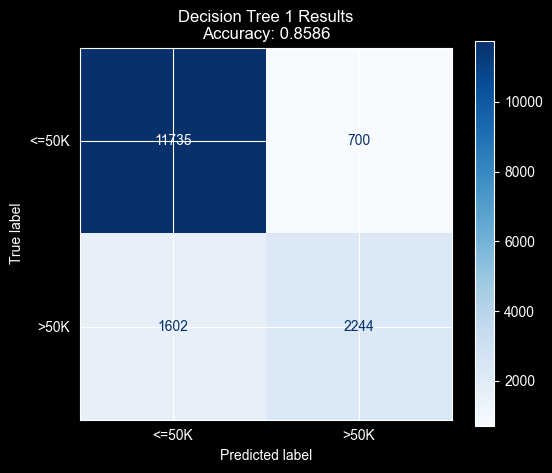

===== Decision Tree 2 =====
Accuracy: 0.8069
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     12435
           1       0.56      0.85      0.68      3846

    accuracy                           0.81     16281
   macro avg       0.75      0.82      0.77     16281
weighted avg       0.85      0.81      0.82     16281

See the impact by changing the values:
0.8586081935999017
0.8068914685830109


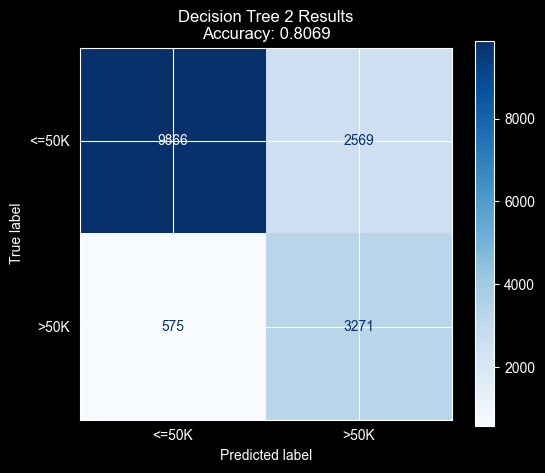

In [51]:
# ── Decision Tree ──────────────────────────────────────
dt_model1 = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)
dt_model1.fit(x_train, y_train)
y_pred_dt = dt_model1.predict(x_test)

print("===== Decision Tree 1 =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

plot_model_results(y_test, y_pred_dt, "Decision Tree 1")

# ── Decision Tree ──────────────────────────────────────
# el balanced de 2llt el accuracy bs zwdt el f1 score w el recall
dt_model2 = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)
dt_model2.fit(x_train, y_train)
y_pred_dt = dt_model2.predict(x_test)
print("===== Decision Tree 2 =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

print("See the impact by changing the values:")
print(accuracy_score(y_test, dt_model1.predict(x_test)))
print(accuracy_score(y_test, dt_model2.predict(x_test)))

plot_model_results(y_test, y_pred_dt, "Decision Tree 2")

===== Random Forest 1 =====
Accuracy: 0.8444
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     12435
           1       0.69      0.61      0.65      3846

    accuracy                           0.84     16281
   macro avg       0.79      0.76      0.77     16281
weighted avg       0.84      0.84      0.84     16281



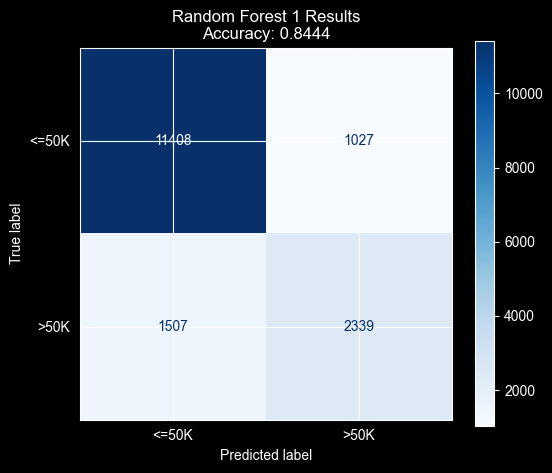

===== Random Forest 2 =====
Accuracy: 0.8395
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     12435
           1       0.67      0.63      0.65      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.77      0.77     16281
weighted avg       0.84      0.84      0.84     16281



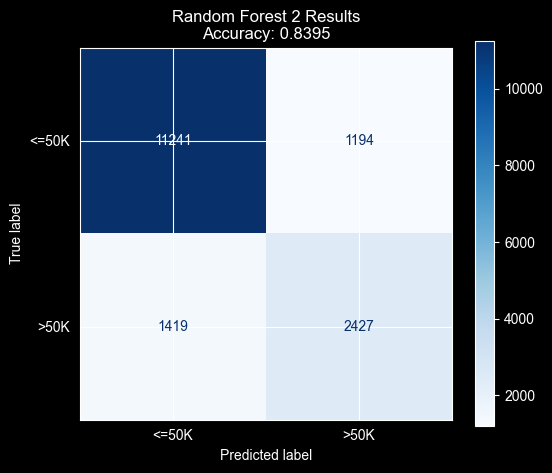

In [52]:
# ── Random Forest ──────────────────────────────────────
rf_model1 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model1.fit(x_train, y_train)
y_pred_rf = rf_model1.predict(x_test)

print("===== Random Forest 1 =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

plot_model_results(y_test, y_pred_rf, "Random Forest 1")

# ── Random Forest ──────────────────────────────────────
rf_model2 = RandomForestClassifier(n_estimators=200, random_state=42,class_weight='balanced')
rf_model2.fit(x_train, y_train)
y_pred_rf = rf_model2.predict(x_test)

print("===== Random Forest 2 =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

plot_model_results(y_test, y_pred_rf, "Random Forest 2")

===== XGBoost =====
Accuracy: 0.8719
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     12435
           1       0.77      0.66      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.83      0.80      0.81     16281
weighted avg       0.87      0.87      0.87     16281



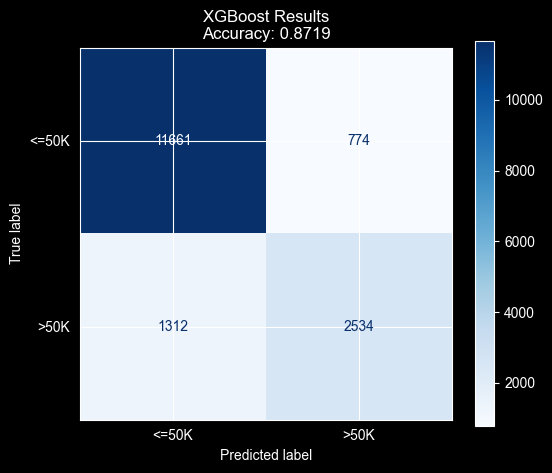

In [53]:
# ── XGBoost ────────────────────────────────────────────
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("===== XGBoost =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

plot_model_results(y_test, y_pred_xgb, "XGBoost")